In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cbook, cm
from matplotlib.colors import LightSource
import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern'], 'figure.figsize': (10,10)})
# plt.rcParams["figure.autolayout"] = True

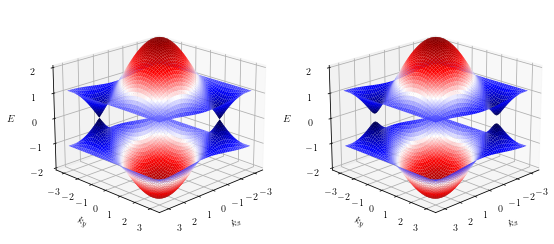

In [18]:
kx = np.linspace(-np.pi, np.pi, 1000)
ky = np.linspace(-np.pi, np.pi, 1000)

KX, KY = np.meshgrid(kx, ky)

kx_warped = (KX) - (KY)/2
ky_warped = (KY)*np.sqrt(3)/2
kx_warped,ky_warped = KX, KY

J = [1,1.1,1]
k = .2
dx = J[0]*np.sin(KX) + J[1]*np.sin(KY)
dy = J[0]*np.cos(KX) + J[1]*np.cos(KY) +J[2]
dz = k*(np.sin(KX) + np.sin(-KY)+ np.sin(KX-KY))

energy = np.sqrt(dx**2 + dy**2 + dz**2)
energy_before = np.sqrt(dx**2 + dy**2)



# plot both surfaces
fig = plt.figure(figsize = (8,3.5))
ax = [fig.add_subplot(1,2,1, projection='3d'),fig.add_subplot(1,2,2, projection='3d')]


ax[0].plot_surface(kx_warped,ky_warped,energy_before, cmap = 'seismic')
ax[0].plot_surface(kx_warped,ky_warped,-energy_before, cmap = 'seismic_r')
ax[0].set_xlabel('$k_x$')
ax[0].set_ylabel('$k_y$')
ax[0].set_zlabel('$E$')
ax[0].set_zlim([-2,2])
ax[0].view_init(20, 45)
# ax[0].set_title('a)')

ax[1].plot_surface(kx_warped,ky_warped,energy, cmap = 'seismic')
ax[1].plot_surface(kx_warped,ky_warped,-energy, cmap = 'seismic_r')
ax[1].set_xlabel('$k_x$')
ax[1].set_ylabel('$k_y$')
ax[1].set_zlabel('$E$')
ax[1].set_zlim([-2,2])
ax[1].view_init(20, 45)
# ax[1].set_title('b)')


# reduce distance to titles
plt.tight_layout()

plt.savefig('honeycomb_bloch.pdf')